In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [63]:
# Read the btc-eth-prices-outliers

df = pd.read_csv(r"C:\Users\HP\Desktop\Data-Science-Foundations\datasets\btc-eth-prices-outliers.csv" , parse_dates= True , index_col= 0)
df

,Bitcoin,Ether
Timestamp,,
2017-04-02,1099.169125,48.55
2017-04-03,1141.813000,44.13
2017-04-04,1141.600363,44.43
2017-04-05,1133.079314,44.90
2017-04-06,1196.307937,43.23
...,...,...
2018-03-28,7960.380000,445.93
2018-03-29,7172.280000,383.90
2018-03-30,6882.531667,393.82


In [64]:
# df.dtypes

# If you run the command above you happen to realise that the column Timestamp is of dtype object

# In the 1st cell we have to go and pass it as date


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2017-04-02 to 2018-04-01
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bitcoin  365 non-null    float64
 1   Ether    362 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


In [66]:
# From the above we can tell that the column for : Timestamp and Bitcoin have no empty values

# Ether column has 3 missing values. We have two options: Drop the null columns or fill them.

In [67]:
x = df['Ether'].isnull()

empty_rows = df[x]
empty_rows

,Bitcoin,Ether
Timestamp,,
2017-12-08,16007.436667,NaN
2017-12-09,15142.834152,NaN
2017-12-10,14869.805000,NaN


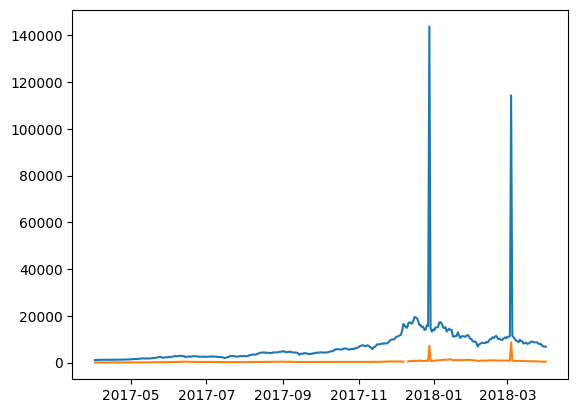

In [68]:
# To visually see this we can try and plot for one to understand where the misssing value are.

# A simple plot

plt.plot(df)


In [69]:
# If you look at the figure above for ether there is discontinuity from around 2017 dec and 2018 jan

# These are the 3 values which were missing values of ether

<Axes: xlabel='Timestamp'>

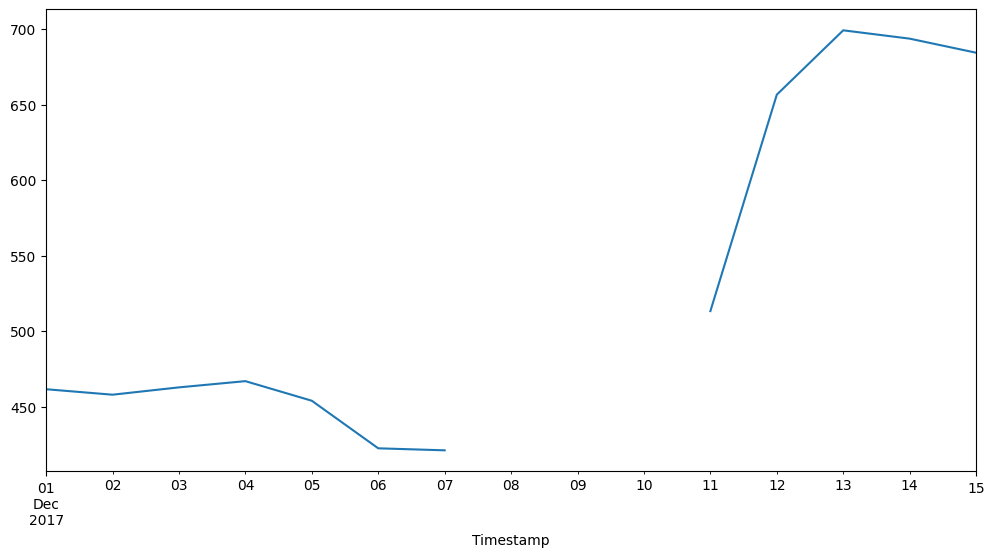

In [70]:
# We can go ahead and plot so that we can visually see

df.loc['2017-12' : '2017-12-15' , 'Ether'].plot(y = 'ether' , figsize = (12 , 6))

# Visually we can see that on 8 , 9 , 10 we are missing values

In [71]:
# We may now decide to fill the missing values using the previous value

df.loc['2017-12-7' : '2017-12-12'].fillna(method = 'bfill')

C:\Users\HP\AppData\Local\Temp\ipykernel_4884\4014760915.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.loc['2017-12-7' : '2017-12-12'].fillna(method = 'bfill')


,Bitcoin,Ether
Timestamp,,
2017-12-07,16501.971667,421.15
2017-12-08,16007.436667,513.29
2017-12-09,15142.834152,513.29
2017-12-10,14869.805000,513.29
2017-12-11,16762.116667,513.29
2017-12-12,17276.393333,656.52


In [75]:
df.fillna(method='bfill' , inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_4884\3844489245.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill' , inplace= True)


In [76]:
# We check if we have null values now

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2017-04-02 to 2018-04-01
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bitcoin  365 non-null    float64
 1   Ether    365 non-null    float64
dtypes: float64(2)
memory usage: 16.7 KB


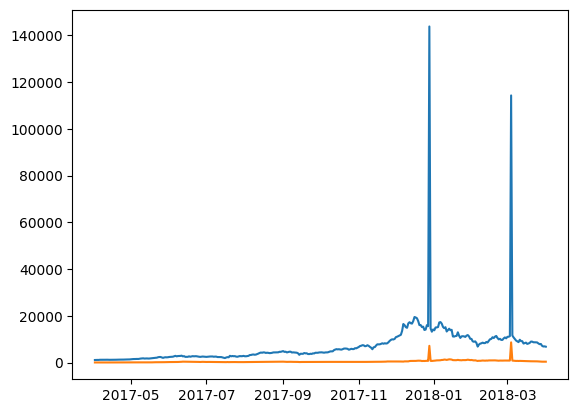

In [77]:
plt.plot(df)

In [ ]:
# If we look at our figure above there seems to be some spikes.

# We can also clean those so that our data is more consistent

# We need to look visually where do we have thos spikes then drop those rows

<Axes: xlabel='Timestamp'>

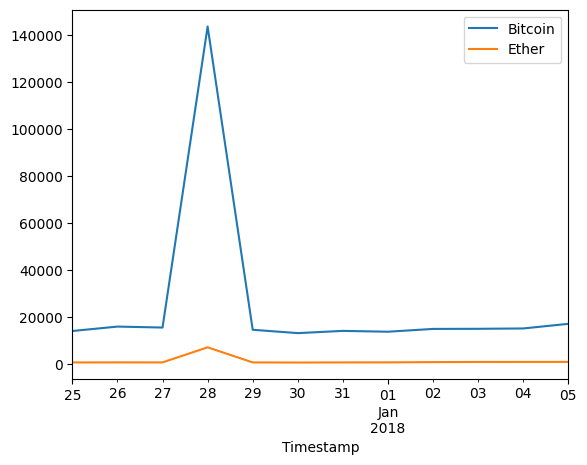

In [78]:
# We try plotting for december of 2017 and early 2018 january

df.loc['2017-12-25' : '2018-01-05'].plot()

In [ ]:
# We have identified one spike 2017-12-28

<Axes: xlabel='Timestamp'>

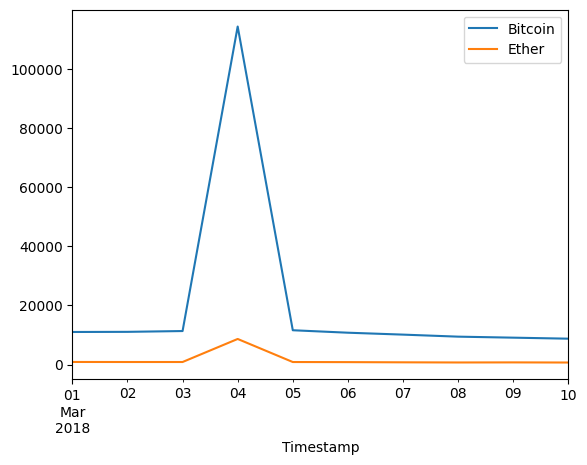

In [79]:
# Look for the second spike in march


df.loc['2018-03-01' : '2018-03-10'].plot()

In [ ]:
# We have a spike on the 2018-03-04

In [80]:
# We are going to drop the following rows 2018-03-04 and 2017-12-28

df_cleaned = df.drop(pd.to_datetime(['2017-12-28' , '2018-03-04']))

<Axes: xlabel='Timestamp'>

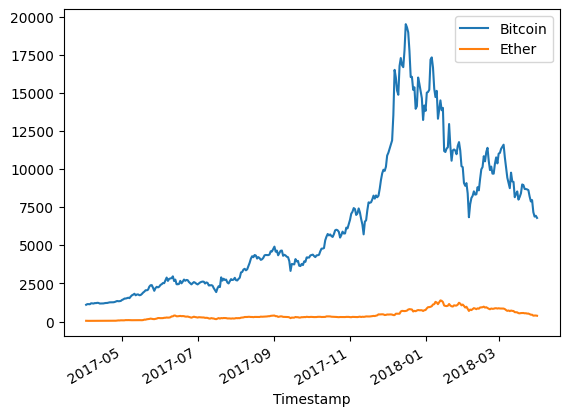

In [ ]:
df_cleaned.plot() #more cleaner

In [82]:
#   We can perform a quick eda on our df

df.describe()

,Bitcoin,Ether
count,365.000000,365.000000
mean,6996.004022,469.609068
std,10186.586168,634.202918
min,1099.169125,42.310000
25%,2585.349186,240.940000
50%,4594.987850,309.490000
75%,9182.843333,656.520000
max,143805.816667,8648.300000


In [83]:
# We perform eda on the cleaned df

df_cleaned.describe()

,Bitcoin,Ether
count,363.000000,363.000000
mean,6323.509186,428.628402
std,4513.757663,306.699311
min,1099.169125,42.310000
25%,2573.739924,239.330000
50%,4580.387480,309.320000
75%,9121.989167,611.855000
max,19498.683333,1385.020000


In [ ]:
# WE GO AHEAD AND VISUALIZE USING DIFFERENT PLOTS AND ANALYZE

In [ ]:
# ETHER HISTOGRAM